# 03 — Hedonic model to AVM

This notebook builds the project's automated valuation model (AVM: a computer estimate of a
home's value, of the kind lenders use to size loans) and measures how wrong it is likely to be.
It uses the Ames sales assembled in notebook 01, restricted to arm's-length transactions, and
scores the model on both a random split and a stricter 2006–08 → 2009–10 split by date. It also
re-scores the first-pass predictions against the 878 holdout prices they were never checked
against (§7): they turn out to have been worse than predicting the average price for every
house. Accuracy is reported as MdAPE (median absolute percentage error, so one large miss cannot
distort it) and PPE10 (the share of estimates within 10% of the sale price).

Terms are defined in [the glossary](../docs/GLOSSARY.md).

The first pass asked whether a regression could fit this data. This notebook asks the lender's
question: if the model values a property used as collateral, how wrong is it likely to be, and
how is that known?

Four things change relative to the original:

1. **One `Pipeline`, fit on training rows only.** Defects #1–#4 in the Model Risk Log
   all came from preprocessing train and test as separate dataframes. Here there is no
   second scaler to fit and no second dummy vocabulary to misalign, so those errors cannot
   occur, and `tests/test_leakage.py` asserts it.
2. **`log(SalePrice)` as the target**, with Duan smearing on the way back to dollars.
3. **Two evaluation regimes reported side by side**: the random split the original used,
   and a 2006–08 → 2009–10 temporal split. The gap between them is the headline comparison.
4. **AVM metrics instead of R².** MdAPE and PPE10 against published institutional thresholds.

In [1]:
import json
import os
import warnings


import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from sklearn.pipeline import Pipeline

from ames.avm import (duan_smearing_factor, morans_i, passes_industry_thresholds,
                      predict_dollars, scorecard)
from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import (ARMS_LENGTH_CONDITION, BASELINE, MDAPE_THRESHOLD, PPE10_THRESHOLD,
                         PROCESSED, RANDOM_TEST_SIZE, SEED,
                         TEMPORAL_TEST_YEARS, TEMPORAL_TRAIN_YEARS)
from ames.data import load_properties
from ames.features import build_preprocessor, prepare, split_feature_types
from ames.warehouse import COMPARABLE_FEATURES, attach_comparables
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
# GridSearchCV fans out to joblib worker processes, which do not inherit an in-process
# warnings filter -- pass it through the environment instead.
os.environ["PYTHONWARNINGS"] = worker_warning_filter()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the ten notebooks read as one report.
KICKER = "03 · Hedonic AVM"
SOURCE = "Source: De Cock (2011) · LightGBM on log price, 1,550 training sales, 862 held out."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

## 1. The modelling universe

Two exclusions, both from notebook 01 and both recommended by De Cock himself.

In [2]:
raw = load_properties()
data = prepare(raw)

universe = data[(data["Sale Condition"] == ARMS_LENGTH_CONDITION)
                & (~data["is_outlier_grlivarea"])].copy()

exclusions = pd.DataFrame({
    "rows": [len(data),
             -(data["Sale Condition"] != ARMS_LENGTH_CONDITION).sum(),
             -((data["Sale Condition"] == ARMS_LENGTH_CONDITION)
               & data["is_outlier_grlivarea"]).sum(),
             len(universe)],
    "reason": ["all sales in the De Cock extract",
               "not arm's-length (Partial / Abnorml / Family / Alloca / AdjLand)",
               "Gr Liv Area > 4,000 sq ft (De Cock 2011, §4) — 1 of the 5 flagged "
               "homes; the other 4 are already excluded as non-arm's-length",
               "valuation universe"],
}, index=["start", "less", "less ", "= universe"])
exclusions

,rows,reason
start,2930,all sales in the De Cock extract
less,-517,not arm's-length (Partial / Abnorml / Family /...
less,-1,"Gr Liv Area > 4,000 sq ft (De Cock 2011, §4) —..."
= universe,2412,valuation universe


Non-arm's-length sales are removed because they are priced by a different process.
Notebook 01 measured the difference:
`Abnorml` transacts 15% below `Normal` per square foot, `Partial` 26% above. A single
model fit across all of them learns an average of two distinct price functions. The
excluded rows come back in notebook 08 as the empirical basis for the foreclosure
haircut in LGD.

In [3]:
TARGET = "SalePrice"
y_log = np.log(universe[TARGET])
numeric, nominal = split_feature_types(universe)
print(f"{len(universe):,} properties · {len(numeric)} numeric + {len(nominal)} nominal features")

2,412 properties · 81 numeric + 20 nominal features


## 2. Two regimes

Regime A, random split: 75/25, comparable to the first-pass design (which
used 95/5; notebook 01 and Model Risk Log defect #6 explain why 5% was too small to
read). Rows from 2010 can train a model that predicts 2006.

Regime B, temporal split: train on 2006–2008, test on 2009–July 2010. This is the
only design that matches how an AVM is used, always forward in time.

In [4]:
random_train_idx, random_test_idx = train_test_split(
    universe.index, test_size=RANDOM_TEST_SIZE, random_state=SEED)

temporal_train_idx = universe.index[universe["temporal_split"] == "train"]
temporal_test_idx = universe.index[universe["temporal_split"] == "test"]

REGIMES = {
    "random": (random_train_idx, random_test_idx),
    "temporal": (temporal_train_idx, temporal_test_idx),
}

pd.DataFrame({
    regime: {
        "train n": len(tr), "test n": len(te),
        "train years": f"{universe.loc[tr, 'Yr Sold'].min():.0f}–{universe.loc[tr, 'Yr Sold'].max():.0f}",
        "test years": f"{universe.loc[te, 'Yr Sold'].min():.0f}–{universe.loc[te, 'Yr Sold'].max():.0f}",
        "train median price": universe.loc[tr, TARGET].median(),
        "test median price": universe.loc[te, TARGET].median(),
    } for regime, (tr, te) in REGIMES.items()
}).T

,train n,test n,train years,test years,train median price,test median price
random,1809,603,2006–2010,2006–2010,159500.0,156000.0
temporal,1550,862,2006–2008,2009–2010,157250.0,160000.0


## 3. Cross-validation design

Hyperparameters are selected with `GroupKFold` on `Neighborhood`: each fold holds out
entire neighborhoods, so a model cannot tune itself by memorising local price levels it
will also see at validation time.

This is deliberately conservative. Holding out a whole
neighborhood means its one-hot column is unseen at validation and routed to the
"infrequent" bucket, so the CV score is pessimistic relative to the deployment case
(where an AVM values a house in a neighborhood it has priced a thousand times). It suits
the task of selecting a penalty strength, because it favours models that generalise
across space over ones that overfit 28 location dummies. The reported figures are the
test-set numbers, not the CV numbers.

In [5]:
CV = GroupKFold(n_splits=5)

MODELS = {
    "Ridge": (Ridge(random_state=SEED, max_iter=50_000),
              {"model__alpha": np.logspace(-1, 3, 25)}, True),
    "Lasso": (Lasso(random_state=SEED, max_iter=50_000),
              {"model__alpha": np.logspace(-5, -1, 25)}, True),
    "ElasticNet": (ElasticNet(random_state=SEED, max_iter=50_000),
                   {"model__alpha": np.logspace(-4, -1, 12),
                    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]}, True),
    # n_jobs=1 on the estimator: GridSearchCV already parallelises across folds, and
    # nesting LightGBM's own thread pool inside it oversubscribes the machine badly.
    "LightGBM": (lgb.LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=1),
                 {"model__n_estimators": [800],
                  "model__learning_rate": [0.02, 0.05],
                  "model__num_leaves": [15, 31],
                  "model__min_child_samples": [10, 25],
                  "model__colsample_bytree": [0.7]}, False),
}

def fit_regime(regime: str):
    """Tune and fit every model on one regime's training rows.  Nothing sees the test set."""
    train_idx, test_idx = REGIMES[regime]
    X_train, X_test = universe.loc[train_idx], universe.loc[test_idx]
    y_train, y_test = y_log.loc[train_idx], y_log.loc[test_idx]
    groups = X_train["Neighborhood"]

    fitted = {}
    for name, (estimator, grid, scale) in MODELS.items():
        pipe = Pipeline([("prep", build_preprocessor(numeric, nominal, scale=scale)),
                         ("model", estimator)])
        search = GridSearchCV(pipe, grid, cv=CV, scoring="neg_root_mean_squared_error",
                              n_jobs=-1, refit=True)
        search.fit(X_train, y_train, groups=groups)

        # Duan smearing is calibrated on *training* residuals only.
        train_resid = y_train - search.best_estimator_.predict(X_train)
        smear = duan_smearing_factor(train_resid)

        log_pred = search.best_estimator_.predict(X_test)
        fitted[name] = {
            "estimator": search.best_estimator_,
            "best_params": search.best_params_,
            "cv_rmse_log": -search.best_score_,
            "smearing": smear,
            "log_pred": log_pred,
            "dollars": predict_dollars(log_pred, smear),
            "actual": np.exp(y_test.to_numpy()),
            "test_idx": test_idx,
        }
        print(f"  {regime:9s} {name:11s} CV log-RMSE {-search.best_score_:.4f}  "
              f"smearing {smear:.4f}")
    return fitted

results = {}
for regime in REGIMES:
    print(f"fitting {regime} regime")
    results[regime] = fit_regime(regime)

fitting random regime


  random    Ridge       CV log-RMSE 0.1016  smearing 1.0034


  random    Lasso       CV log-RMSE 0.1026  smearing 1.0036


  random    ElasticNet  CV log-RMSE 0.1026  smearing 1.0036


  random    LightGBM    CV log-RMSE 0.1080  smearing 1.0001
fitting temporal regime


  temporal  Ridge       CV log-RMSE 0.1006  smearing 1.0035


  temporal  Lasso       CV log-RMSE 0.1005  smearing 1.0036


  temporal  ElasticNet  CV log-RMSE 0.1006  smearing 1.0037


  temporal  LightGBM    CV log-RMSE 0.1060  smearing 1.0005


### Duan smearing: why the dollar figures would otherwise be biased low

A model fit on `log(price)` predicts the conditional mean of the log, which
exponentiates to the conditional median of price rather than its mean. For a right-skewed
target that under-states every dollar valuation, and by more at the top of the
distribution. Duan's non-parametric correction multiplies by the sample mean of
`exp(residual)`, assuming nothing about the residual distribution.

In [6]:
smear_effect = pd.DataFrame({
    (regime, name): {
        "smearing factor": r["smearing"],
        "uplift": r["smearing"] - 1,
        "MdAPE without correction": np.median(np.abs(
            (np.exp(r["log_pred"]) - r["actual"]) / r["actual"])),
        "MdAPE with correction": np.median(np.abs(
            (r["dollars"] - r["actual"]) / r["actual"])),
        "mean signed error without": np.mean(
            (np.exp(r["log_pred"]) - r["actual"]) / r["actual"]),
        "mean signed error with": np.mean((r["dollars"] - r["actual"]) / r["actual"]),
    } for regime, models in results.items() for name, r in models.items()
}).T.round(4)
smear_effect

smearing factor  uplift  MdAPE without correction  MdAPE with correction  mean signed error without  \
random   Ridge                1.0034  0.0034                    0.0546                 0.0557                     0.0076   
         Lasso                1.0036  0.0036                    0.0543                 0.0543                     0.0080   
         ElasticNet           1.0036  0.0036                    0.0548                 0.0538                     0.0083   
         LightGBM             1.0001  0.0001                    0.0514                 0.0515                     0.0097   
temporal Ridge                1.0035  0.0035                    0.0582                 0.0582                    -0.0027   
         Lasso                1.0036  0.0036                    0.0574                 0.0571                     0.0002   
         ElasticNet           1.0037  0.0037                    0.0572                 0.0571                     0.0008   
         LightGBM             1.0005  0.0005                    0.0551                 0.0549                    -0.0016   

                     mean signed error with  
random   Ridge                       0.0111  
         Lasso                       0.0116  
         ElasticNet                  0.0119  
         LightGBM                    0.0098  
temporal Ridge                       0.0008  
         Lasso                       0.0038  
         ElasticNet                  0.0044  
         LightGBM                   -0.0011

The correction is small in MdAPE (a median, so a uniform multiplicative shift
barely moves it) and materially changes the mean signed error, which is the
quantity that matters for a loan book. A 2% systematic under-valuation across 2,400
properties is 2% of systematically over-stated LTV, in the same direction, on every
loan. Errors of that kind do not diversify away.

## 4. The scorecard

MdAPE and the PPE family, against the thresholds institutional AVMs are held to:
MdAPE < 5% and PPE10 > 75%.

In [7]:
cards = pd.DataFrame({
    (regime, name): scorecard(r["actual"], r["dollars"])
    for regime, models in results.items() for name, r in models.items()
}).T
cards.index.names = ["regime", "model"]
cards_display = cards.copy()
cards_display["n"] = cards_display["n"].astype(int)
cards_display.round(4)

n   MdAPE    PPE5   PPE10   PPE20   PPE25     FSD  mean_signed_error        RMSE  RMSE_log      R2
regime   model                                                                                                           
random   Ridge       603  0.0557  0.4594  0.7695  0.9585  0.9751  0.0930             0.0111  18092.6849    0.0931  0.9324
         Lasso       603  0.0543  0.4627  0.7711  0.9569  0.9751  0.0927             0.0116  18133.8523    0.0929  0.9320
         ElasticNet  603  0.0538  0.4693  0.7695  0.9569  0.9751  0.0932             0.0119  18151.3090    0.0934  0.9319
         LightGBM    603  0.0515  0.4925  0.7678  0.9602  0.9801  0.0902             0.0098  15869.1920    0.0903  0.9480
temporal Ridge       862  0.0582  0.4466  0.7564  0.9606  0.9849  0.0942             0.0008  16578.7249    0.0942  0.9474
         Lasso       862  0.0571  0.4455  0.7691  0.9606  0.9826  0.0936             0.0038  16635.0359    0.0936  0.9471
         ElasticNet  862  0.0571  0.4490  0.7633  0.9606  0.9814  0.0938             0.0044  16661.3577    0.0938  0.9469
         LightGBM    862  0.0549  0.4617  0.7657  0.9536  0.9803  0.0943            -0.0011  17551.0366    0.0944  0.9411

In [8]:
best_by_regime = {regime: cards.loc[regime]["MdAPE"].idxmin() for regime in REGIMES}
print("best model by MdAPE:", best_by_regime)

for regime, model in best_by_regime.items():
    checks = passes_industry_thresholds(cards.loc[(regime, model)])
    status = "  ".join(f"{k}: {'PASS' if v else 'FAIL'}" for k, v in checks.items())
    print(f"{regime:9s} {model:11s} -> {status}")

best model by MdAPE: {'random': 'LightGBM', 'temporal': 'LightGBM'}
random    LightGBM    -> MdAPE < 5%: FAIL  PPE10 > 75%: PASS
temporal  LightGBM    -> MdAPE < 5%: FAIL  PPE10 > 75%: PASS


**Both regimes fail the 5% MdAPE bar and clear the 75% PPE10 bar.** An R² of 0.95 would look
better in a headline but says nothing about this. A typical valuation
from this model misses by about 5.5%; institutional AVMs are expected to be inside 5%.

A model trained on 1,550 transactions in one small city is not going to match a
production AVM trained on millions of records with tax-assessment, listing and
permit feeds. The useful output is a measured distance from the bar, with the interval
width in notebook 04 indicating how much confidence to put on any individual number.

### How much did the temporal split cost?

In [9]:
headline = pd.DataFrame({
    model: {
        "MdAPE, random": cards.loc[("random", model), "MdAPE"],
        "MdAPE, temporal": cards.loc[("temporal", model), "MdAPE"],
        "degradation": cards.loc[("temporal", model), "MdAPE"] / cards.loc[("random", model), "MdAPE"] - 1,
        "PPE10, random": cards.loc[("random", model), "PPE10"],
        "PPE10, temporal": cards.loc[("temporal", model), "PPE10"],
        "RMSE, random": cards.loc[("random", model), "RMSE"],
        "RMSE, temporal": cards.loc[("temporal", model), "RMSE"],
    } for model in MODELS
}).T
headline.round(4)

,"MdAPE, random","MdAPE, temporal",degradation,"PPE10, random","PPE10, temporal","RMSE, random","RMSE, temporal"
Ridge,0.0557,0.0582,0.0433,0.7695,0.7564,18092.6849,16578.7249
Lasso,0.0543,0.0571,0.0515,0.7711,0.7691,18133.8523,16635.0359
ElasticNet,0.0538,0.0571,0.0607,0.7695,0.7633,18151.3090,16661.3577
LightGBM,0.0515,0.0549,0.0660,0.7678,0.7657,15869.1920,17551.0366


  saved reports/figures/03_regime_comparison.png


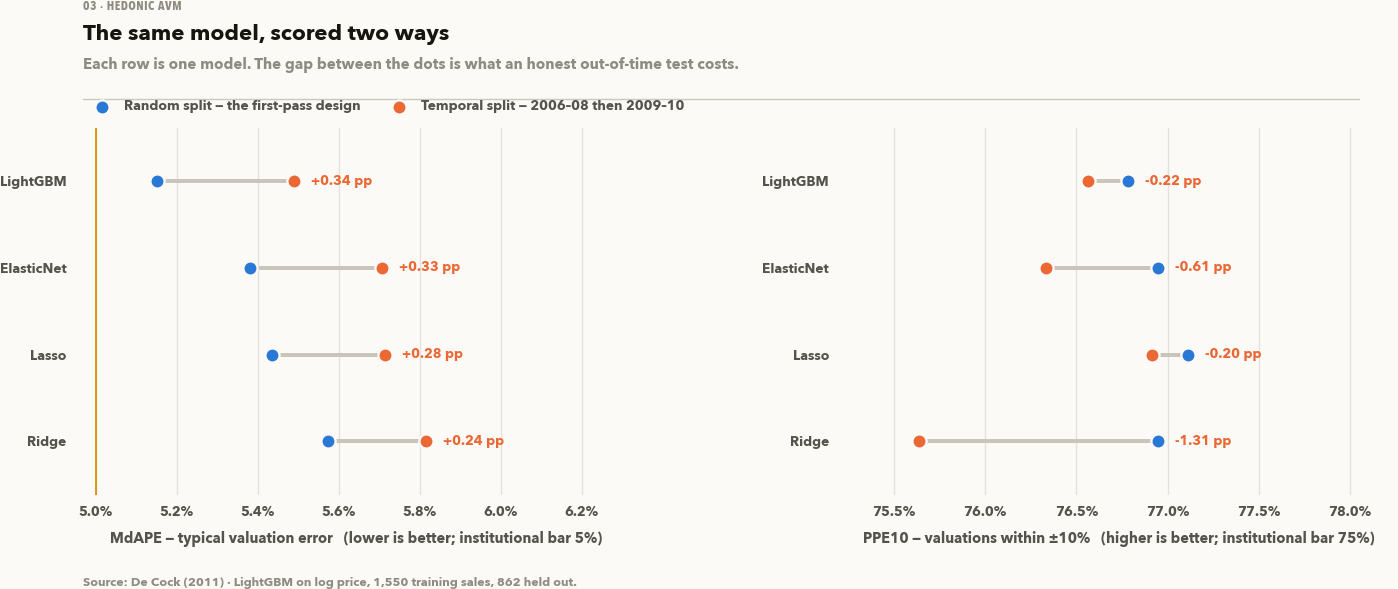

In [10]:
models = list(MODELS)
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9))

for ax, metric, threshold, xlabel in [
    (axes[0], "MdAPE", MDAPE_THRESHOLD,
     f"MdAPE — typical valuation error   (lower is better; institutional bar {MDAPE_THRESHOLD:.0%})"),
    (axes[1], "PPE10", PPE10_THRESHOLD,
     f"PPE10 — valuations within ±10%   (higher is better; institutional bar {PPE10_THRESHOLD:.0%})"),
]:
    rnd = [cards.loc[("random", m), metric] for m in models]
    tmp = [cards.loc[("temporal", m), metric] for m in models]
    dumbbell(ax, models, rnd, tmp,
             "Random split — the first-pass design",
             "Temporal split — 2006–08 then 2009–10",
             formatter=pct1)
    # The bar is drawn, not labelled: naming it in the axis label keeps the margins clear.
    ax.axvline(threshold, color=STATUS["warning"], lw=1.2, zorder=1)

    span = max(max(rnd), max(tmp)) - min(min(rnd), min(tmp))
    ax.set_xlim(min(min(rnd), min(tmp)) - span * 0.30,
                max(max(rnd), max(tmp)) + span * 0.78)
    # The change, written beside the dot it belongs to rather than out in the margin.
    for i, (a, b) in enumerate(zip(rnd, tmp)):
        delta = (b - a) * 100
        worse = delta > 0 if metric == "MdAPE" else delta < 0
        annotate(ax, max(a, b), i, f"{delta:+.2f} pp",
                 color=CONTRAST if worse else STATUS["good"], offset=(11, 0))
    ax.set_xlabel(xlabel)

legend_above(axes[0], ncol=2)
finish(fig, "The same model, scored two ways",
       "Each row is one model. The gap between the dots is what an honest out-of-time "
       "test costs.")
save(fig, "03_regime_comparison")
plt.show()

**The gap is small: 4–7% relative degradation.** This does not show that random splitting is
safe. Notebook 02 explains the result: Ames fell 4.3% peak-to-trough
against 27.4% nationally, because Iowa State's employment base makes the local market
nearly acyclical. There is barely any regime to shift across.

This number is therefore a lower bound. The same experiment
in Phoenix or Las Vegas over 2006–2010 would show a far larger gap, and concluding from this
result that split design does not matter would mean generalising
from the one market where it almost doesn't. It is also why the credit stress in
notebook 08 imposes the supervisory −30% shock rather than learning a downturn from
Ames's own history, which does not contain one.

RMSE and MdAPE also disagree about the best model on the temporal split:
LightGBM has the lower MdAPE (typical error) while Ridge has the lower RMSE (tail
error). They answer different questions, and an AVM is judged on the first.

## 5. Error structure

Where the errors fall matters more than their average size.

  saved reports/figures/03_error_structure.png


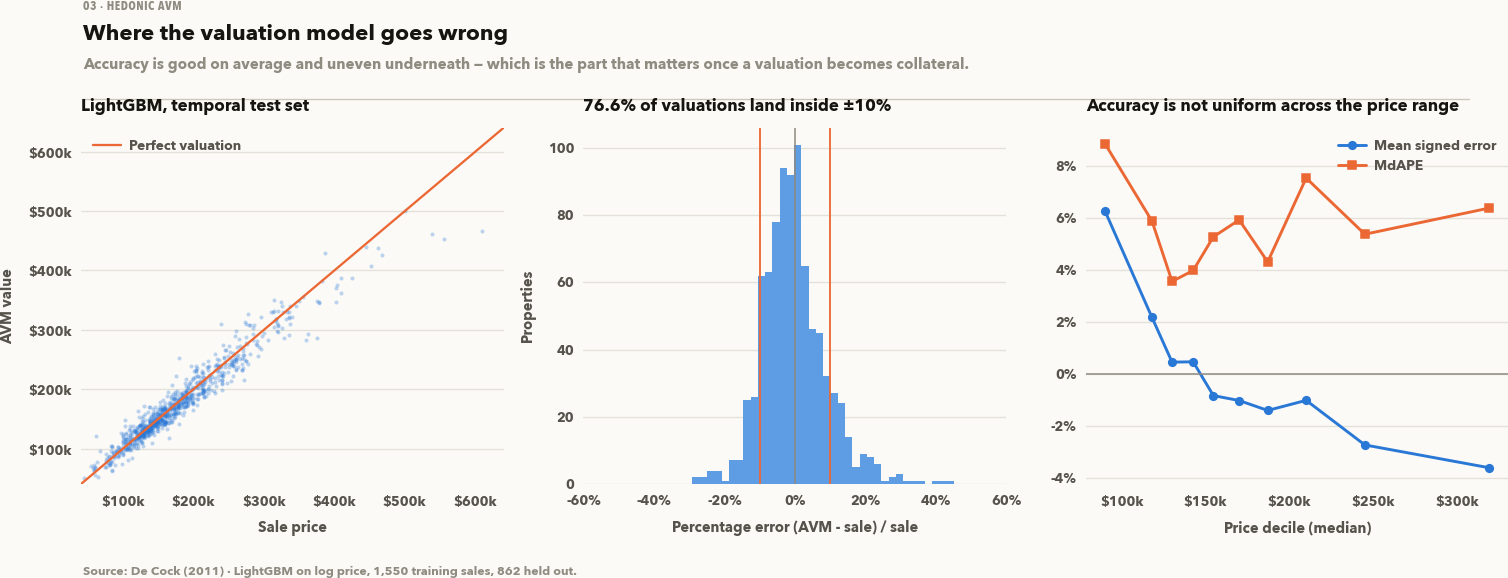

In [11]:
best_regime, best_model = "temporal", best_by_regime["temporal"]
best = results[best_regime][best_model]
test_rows = universe.loc[best["test_idx"]]
errors = pd.DataFrame({
    "actual": best["actual"], "predicted": best["dollars"],
    "pe": (best["dollars"] - best["actual"]) / best["actual"],
}, index=best["test_idx"])

fig, axes = plt.subplots(1, 3, figsize=(14.0, 5.8))

lims = [errors[["actual", "predicted"]].min().min() * 0.9,
        errors[["actual", "predicted"]].max().max() * 1.05]
axes[0].scatter(errors["actual"], errors["predicted"], s=7, alpha=0.3,
                color=BLUE, linewidths=0)
axes[0].plot(lims, lims, color=ORANGE, lw=1.5, label="Perfect valuation")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].xaxis.set_major_formatter(money); axes[0].yaxis.set_major_formatter(money)
axes[0].set_xlabel("Sale price"); axes[0].set_ylabel("AVM value")
axes[0].legend(loc="upper left")
titled(axes[0], f"{best_model}, temporal test set")

axes[1].hist(errors["pe"], bins=60, color=SUBJECT_FILL)
axes[1].axvline(0, color=INK_MUTED, lw=1)
for t, c in [(-0.10, ORANGE), (0.10, ORANGE)]:
    axes[1].axvline(t, color=c, lw=1.2, linestyle="-")
axes[1].xaxis.set_major_formatter(pct)
axes[1].set_xlim(-0.6, 0.6)
axes[1].set_xlabel("Percentage error (AVM - sale) / sale")
axes[1].set_ylabel("Properties")
ppe10 = cards.loc[(best_regime, best_model), "PPE10"]
titled(axes[1], f"{ppe10:.1%} of valuations land inside ±10%")

deciles = pd.qcut(errors["actual"], 10, labels=False)
by_decile = errors.groupby(deciles).agg(
    median_price=("actual", "median"), mdape=("pe", lambda s: np.median(np.abs(s))),
    bias=("pe", "mean"))
axes[2].plot(by_decile["median_price"], by_decile["bias"], color=BLUE,
             marker="o", markersize=5, label="Mean signed error")
axes[2].plot(by_decile["median_price"], by_decile["mdape"], color=ORANGE,
             marker="s", markersize=5, label="MdAPE")
axes[2].axhline(0, color=INK_MUTED, lw=1)
axes[2].xaxis.set_major_formatter(money); axes[2].yaxis.set_major_formatter(pct)
axes[2].set_xlabel("Price decile (median)")
axes[2].legend(loc="upper right")
titled(axes[2], "Accuracy is not uniform across the price range")

finish(fig, "Where the valuation model goes wrong",
       "Accuracy is good on average and uneven underneath — which is the part that matters "
       "once a valuation becomes collateral.")
save(fig, "03_error_structure")
plt.show()

In [12]:
by_decile.round(4)

,median_price,mdape,bias
actual,,,
0,90000.0,0.0886,0.0627
1,118000.0,0.0589,0.0218
2,130000.0,0.0356,0.0046
3,142575.0,0.0398,0.0047
4,154650.0,0.0528,-0.0083
5,170000.0,0.0593,-0.0102
6,187050.0,0.0432,-0.0140
7,210000.0,0.0754,-0.0102
8,245000.0,0.0538,-0.0273


The third panel groups errors by sale-price decile and slopes from over-valuation at
the cheap end to under-valuation at the top. Grouping by the quantity
being estimated produces most of that slope even for a model that is unbiased by
construction, and notebook 04 separates the two effects. The real over-valuation at the cheap end
is about 2–3%, and none remains at the top.

## 6. Reading the hedonic model

The penalised linear model is the interpretable one. Because the target is
`log(price)` and the features are standardised, a coefficient is the percentage change
in price per one-standard-deviation change in the feature, holding the rest constant.

In [13]:
linear_name = min(("Ridge", "Lasso", "ElasticNet"),
                  key=lambda m: cards.loc[("temporal", m), "MdAPE"])
linear = results["temporal"][linear_name]["estimator"]
feature_names = linear.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(linear.named_steps["model"].coef_, index=feature_names)

top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)
# exp(beta) - 1 converts a log-target coefficient into a percentage price effect.
effects = (np.exp(top_coefs) - 1).sort_values()

### What each feature is worth, in dollars

A penalised coefficient is expressed per standard deviation, which is not a unit anyone
owns. Converted to dollars per natural unit (a square foot, a garage bay, one step up
a quality ladder), the same model produces statements a homeowner or an appraiser can
check against their own house.

In [14]:
median_price = universe[TARGET].median()
sd = universe[numeric].std()

def marginal_effect(feature: str) -> float:
    """Percentage price change per one *natural* unit of the feature."""
    if feature not in coefs.index or feature not in sd.index or sd[feature] == 0:
        return np.nan
    return np.exp(coefs[feature] / sd[feature]) - 1

interpretable = ["Gr Liv Area", "total_sf", "Lot Area", "Overall Qual", "Kitchen Qual",
                 "Exter Qual", "Bsmt Qual", "Heating QC", "Fireplaces", "total_baths",
                 "Garage Cars", "house_age", "years_since_remodel", "total_porch_sf"]
# label, natural-unit multiplier.  Area features are shown per 100 sq ft: a single
# square foot is not a decision anyone makes, and on a shared dollar axis it reads as zero.
units = {
    "Overall Qual": ("Overall quality", "one grade, 1-10", 1),
    "Kitchen Qual": ("Kitchen quality", "one grade, poor to excellent", 1),
    "Exter Qual": ("Exterior quality", "one grade, poor to excellent", 1),
    "Bsmt Qual": ("Basement quality", "one grade, poor to excellent", 1),
    "Heating QC": ("Heating quality", "one grade, poor to excellent", 1),
    "Garage Cars": ("Garage", "one more car bay", 1),
    "Fireplaces": ("Fireplace", "one more", 1),
    "total_baths": ("Bathrooms", "one more full bath", 1),
    "Gr Liv Area": ("Living area", "100 sq ft", 100),
    "total_sf": ("Total floor area", "100 sq ft", 100),
    "total_porch_sf": ("Porch & deck", "100 sq ft", 100),
    "Lot Area": ("Lot", "1,000 sq ft", 1000),
    "house_age": ("Age of the house", "one more year", 1),
    "years_since_remodel": ("Years since remodel", "one more year", 1),
}

hedonic = pd.DataFrame([{
    "feature": units[f][0], "unit": units[f][1],
    "price effect %": marginal_effect(f) * units[f][2],
    "$ at the median home": marginal_effect(f) * units[f][2] * median_price,
} for f in interpretable if f in coefs.index]).dropna()
# Sorted by dollar impact: a percentage "per unit" is not comparable across units,
# because one square foot and one quality grade are not the same size of change.
hedonic = hedonic.sort_values("$ at the median home", key=abs,
                              ascending=False).reset_index(drop=True)
hedonic.round(4)

,feature,unit,price effect %,$ at the median home
0,Overall quality,"one grade, 1-10",0.0605,9599.5667
1,Garage,one more car bay,0.0234,3710.4554
2,Heating quality,"one grade, poor to excellent",0.0177,2814.2071
3,Kitchen quality,"one grade, poor to excellent",0.0174,2755.1861
4,Living area,100 sq ft,0.0167,2658.7740
5,Fireplace,one more,0.0155,2466.9302
6,Exterior quality,"one grade, poor to excellent",0.0137,2180.5108
7,Total floor area,100 sq ft,0.0094,1487.1149
8,Bathrooms,one more full bath,0.0070,1109.2214
9,Basement quality,"one grade, poor to excellent",0.0060,948.9669


  saved reports/figures/03_hedonic_coefficients.png


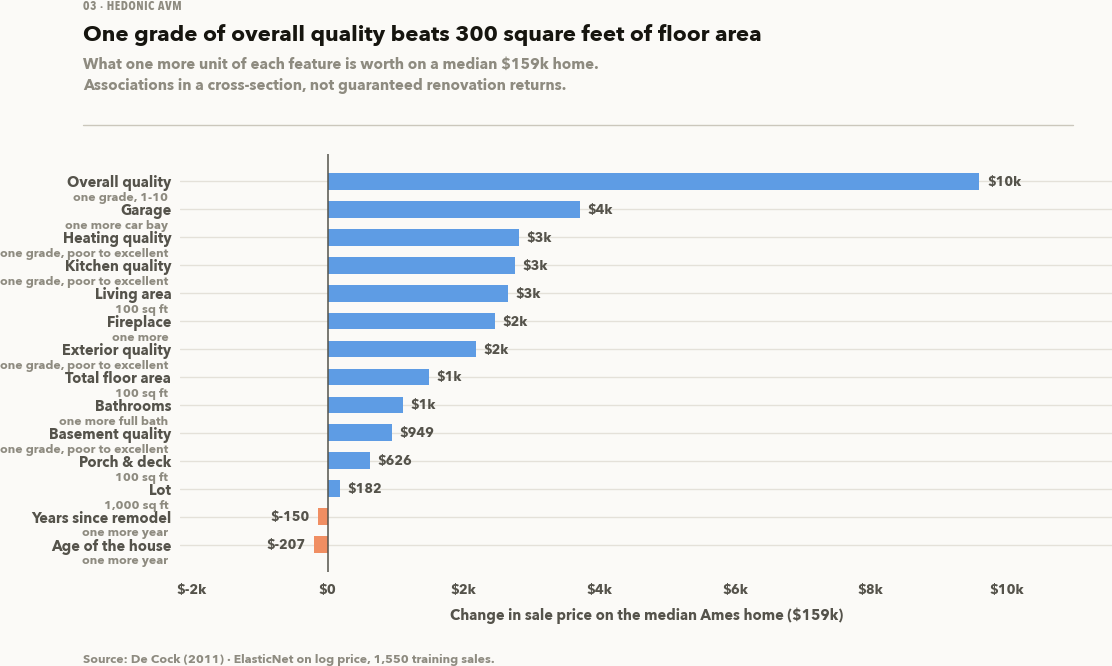

In [15]:
# Dollars per natural unit, not coefficients per standard deviation: "one more grade of
# kitchen quality" is a thing an owner can act on; "one standard deviation" is not.
fig, ax = plt.subplots(figsize=(10.4, 6.6))
plot = hedonic.sort_values("$ at the median home")
y = np.arange(len(plot))
bars = ax.barh(y, plot["$ at the median home"], height=0.6,
               color=[CONTRAST_FILL if v < 0 else SUBJECT_FILL
                      for v in plot["$ at the median home"]])
ax.set_yticks(y, plot["feature"], fontsize=9.5)
for i, unit in enumerate(plot["unit"]):
    ax.annotate(unit, xy=(0, i), xycoords=("axes fraction", "data"), xytext=(-8, -11),
                textcoords="offset points", ha="right", va="center", fontsize=8,
                color=INK_MUTED, annotation_clip=False)
ax.axvline(0, color=INK_SECONDARY, lw=1)
bar_labels(ax, bars, [money(v) for v in plot["$ at the median home"]])
ax.xaxis.set_major_formatter(money)
ax.margins(x=0.20)
ax.set_xlabel(f"Change in sale price on the median Ames home ({money(median_price)})")
finish(fig, "One grade of overall quality beats 300 square feet of floor area",
       f"What one more unit of each feature is worth on a median {money(median_price)} "
       f"home.\nAssociations in a cross-section, not guaranteed renovation returns.",
       source=f"Source: De Cock (2011) · {linear_name} on log price, 1,550 training sales.")
save(fig, "03_hedonic_coefficients")
plt.show()

These are the numbers that answer a homeowner's question. On the median Ames home
($158,750), one grade of Overall Quality is worth roughly **$9,600**, about 360 square
feet of living area at the model's implied $27/sq ft. A garage bay is worth ~$3,700,
a fireplace ~$2,500, and each year of age costs ~$207.

The ranking is the actionable part: quality grades dominate square footage per unit of
change, which translates into a concrete renovation recommendation rather than a model diagnostic.

Two cautions belong next to this table:

- These are associations in a cross-section, not causal renovation returns. Homes
  with excellent kitchens differ from homes with typical kitchens in ways the model does
  not observe.
- The penalised coefficients are shrunk toward zero and, with correlated features
  like `Gr Liv Area` and `total_sf`, credit is split between them somewhat arbitrarily.

### Does the boosted model agree with the linear one?

SHAP attributes each valuation across features, but its units are log-price
contributions, which are hard to present to a general reader. It is used here as a
cross-check: if the interpretable model and the accurate one disagree about what
matters, at least one of them is picking up noise.

In [16]:
import shap

gbm = results["temporal"]["LightGBM"]["estimator"]
gbm_prep, gbm_model = gbm.named_steps["prep"], gbm.named_steps["model"]
gbm_features = gbm_prep.get_feature_names_out()

shap_sample = universe.loc[REGIMES["temporal"][1]].sample(
    min(600, len(REGIMES["temporal"][1])), random_state=SEED)
X_shap = pd.DataFrame(gbm_prep.transform(shap_sample), columns=gbm_features)
shap_values = shap.TreeExplainer(gbm_model).shap_values(X_shap)

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=gbm_features)
top_shap = mean_abs.sort_values(ascending=False).head(18)[::-1]
mean_abs.sort_values(ascending=False).head(10).round(4).to_frame("mean |SHAP|")

,mean |SHAP|
qual_x_sf,0.1292
total_sf,0.0538
Kitchen Qual,0.0204
Overall Qual,0.0173
Overall Cond,0.0170
Lot Area,0.0155
BsmtFin Type 1,0.0152
total_baths,0.0146
Fireplaces,0.0140
Year Remod/Add,0.0119


In [17]:
overlap = set(top_shap.index[-10:]) & set(top_coefs.index[:10])
print(f"features in both the top-10 hedonic coefficients and the top-10 SHAP: "
      f"{sorted(overlap) if overlap else 'none'}")

features in both the top-10 hedonic coefficients and the top-10 SHAP: ['Overall Cond', 'Overall Qual', 'total_sf']


## 7. Re-scoring the first-pass predictions

The first pass could never measure its own test error because the 878 holdout labels were
withheld. With them available, the cost of the defects can be measured directly.

For a like-for-like comparison the corrected model here is trained on the same
2,051 training rows and asked for the same 878 held-out rows.

In [18]:
holdout_ids = pd.read_csv(BASELINE / "test.csv")[["Id", "PID"]]
submission = pd.read_csv(BASELINE / "MY_submission.csv")
original = (submission.merge(holdout_ids, on="Id")
            .merge(raw[["PID", TARGET]], on="PID", suffixes=("_predicted", "_actual")))
print(f"{len(original)} of {len(submission)} submitted rows matched to a true sale price")

fit_rows = data[data["baseline_split"] == "train"]
score_rows = data[data["baseline_split"] == "test"].set_index("PID").loc[original["PID"]]

replication = {}
for name in ("Ridge", "LightGBM"):
    estimator, grid, scale = MODELS[name]
    pipe = Pipeline([("prep", build_preprocessor(numeric, nominal, scale=scale)),
                     ("model", estimator)])
    search = GridSearchCV(pipe, grid, cv=CV, scoring="neg_root_mean_squared_error", n_jobs=-1)
    search.fit(fit_rows, np.log(fit_rows[TARGET]),
               groups=fit_rows["Neighborhood"])
    smear = duan_smearing_factor(np.log(fit_rows[TARGET])
                                 - search.best_estimator_.predict(fit_rows))
    replication[name] = predict_dollars(
        search.best_estimator_.predict(score_rows.reset_index()), smear)

rescore = pd.DataFrame({
    "first pass (as filed)": scorecard(original["SalePrice_actual"],
                                                original["SalePrice_predicted"]),
    **{f"corrected pipeline — {k}": scorecard(original["SalePrice_actual"], v)
       for k, v in replication.items()},
}).T
rescore["n"] = rescore["n"].astype(int)
rescore.round(4)

878 of 878 submitted rows matched to a true sale price


,n,MdAPE,PPE5,PPE10,PPE20,PPE25,FSD,mean_signed_error,RMSE,RMSE_log,R2
first pass (as filed),878,0.3690,0.0661,0.1390,0.2916,0.3588,0.5811,0.1929,112153.7382,0.5809,-0.9004
corrected pipeline — Ridge,878,0.0651,0.4066,0.6845,0.9112,0.9487,0.1217,0.0145,24566.9639,0.1218,0.9088
corrected pipeline — LightGBM,878,0.0511,0.4943,0.7688,0.9351,0.9579,0.1122,0.0116,24995.8879,0.1123,0.9056


  saved reports/figures/03_first_pass_rescore.png


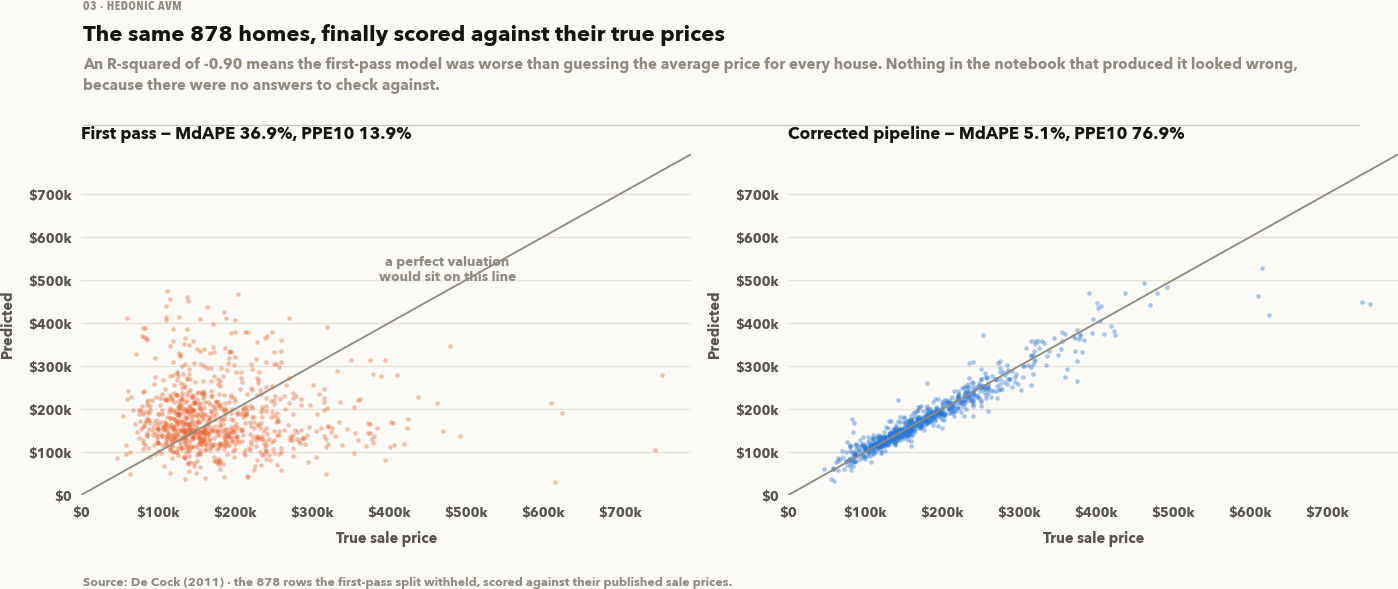

In [19]:
orig_card = rescore.loc["first pass (as filed)"]
best_fix = rescore.drop(index="first pass (as filed)")["MdAPE"].idxmin()
fix_card = rescore.loc[best_fix]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.9))
axes[0].scatter(original["SalePrice_actual"], original["SalePrice_predicted"],
                s=9, alpha=0.4, color=ORANGE, linewidths=0)
lim = [0, max(original["SalePrice_actual"].max(),
              original["SalePrice_predicted"].max()) * 1.05]
axes[0].plot(lim, lim, color=INK_MUTED, lw=1.2)
annotate(axes[0], lim[1] * 0.60, lim[1] * 0.66, "a perfect valuation\nwould sit on this line",
         color=INK_MUTED, offset=(0, 0), ha="center")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].xaxis.set_major_formatter(money); axes[0].yaxis.set_major_formatter(money)
axes[0].set_xlabel("True sale price"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"First pass — MdAPE {orig_card['MdAPE']:.1%}, "
                  f"PPE10 {orig_card['PPE10']:.1%}")

axes[1].scatter(original["SalePrice_actual"], replication[best_fix.split("— ")[1]],
                s=9, alpha=0.4, color=BLUE, linewidths=0)
axes[1].plot(lim, lim, color=INK_MUTED, lw=1.2)
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].xaxis.set_major_formatter(money); axes[1].yaxis.set_major_formatter(money)
axes[1].set_xlabel("True sale price"); axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Corrected pipeline — MdAPE {fix_card['MdAPE']:.1%}, "
                  f"PPE10 {fix_card['PPE10']:.1%}")

finish(fig, "The same 878 homes, finally scored against their true prices",
       "An R-squared of -0.90 means the first-pass model was worse than guessing the "
       "average price for every house. Nothing in the notebook that produced it looked "
       "wrong, because there were no answers to check against.",
       source="Source: De Cock (2011) · the 878 rows the first-pass split withheld, "
              "scored against their published sale prices.")
save(fig, "03_first_pass_rescore")
plt.show()

In [20]:
print(f"RMSE:  {money(orig_card['RMSE'])} -> {money(fix_card['RMSE'])}  "
      f"({fix_card['RMSE'] / orig_card['RMSE'] - 1:+.1%})")
print(f"MdAPE: {orig_card['MdAPE']:.1%} -> {fix_card['MdAPE']:.1%}")
print(f"PPE10: {orig_card['PPE10']:.1%} -> {fix_card['PPE10']:.1%}")

RMSE:  $112k -> $25k  (-77.7%)
MdAPE: 36.9% -> 5.1%
PPE10: 13.9% -> 76.9%


**The first-pass predictions scored MdAPE 36.9% with R² of −0.90.**

A negative R² means that model was worse than predicting the training mean for every
house. Only 13.9% of its valuations landed within 10% of the true price, against
76.9% for the corrected pipeline on the same 878 homes; RMSE fell 78%, from $112k to
$25k.

This is what Model Risk Log defects #1 and #2 cost, and it is the strongest argument in
the project for the structural fixes. The failure was invisible
from inside the notebook that produced it: the code ran without error, the predicted-price
histogram looked like a plausible distribution of Ames house prices, and there were no
test labels to check against. Recovering the labels was the only way to detect it.

## 8. Persist artifacts for notebooks 04–10

In [21]:
frames = []
for regime, models in results.items():
    for name, r in models.items():
        rows = universe.loc[r["test_idx"]]
        frames.append(pd.DataFrame({
            "PID": rows["PID"].to_numpy(),
            "regime": regime, "model": name,
            "actual": r["actual"], "predicted": r["dollars"],
            "log_actual": np.log(r["actual"]), "log_pred": r["log_pred"],
            "Neighborhood": rows["Neighborhood"].to_numpy(),
            "Latitude": rows["Latitude"].to_numpy(),
            "Longitude": rows["Longitude"].to_numpy(),
            "Yr Sold": rows["Yr Sold"].to_numpy(),
            "sale_date": rows["sale_date"].to_numpy(),
            "Gr Liv Area": rows["Gr Liv Area"].to_numpy(),
            "Bedroom AbvGr": rows["Bedroom AbvGr"].to_numpy(),
            "Overall Qual": rows["Overall Qual"].to_numpy(),
        }))
predictions = pd.concat(frames, ignore_index=True)
predictions.to_parquet(PROCESSED / "avm_predictions.parquet", index=False)

joblib.dump({
    "estimator": results["temporal"][best_by_regime["temporal"]]["estimator"],
    "model_name": best_by_regime["temporal"],
    "smearing": results["temporal"][best_by_regime["temporal"]]["smearing"],
    "numeric": numeric, "nominal": nominal, "target": TARGET,
}, PROCESSED / "avm_model.joblib")

cards.to_csv(PROCESSED / "avm_scorecards.csv")
(PROCESSED / "avm_summary.json").write_text(json.dumps({
    "best_model_temporal": best_by_regime["temporal"],
    "best_model_random": best_by_regime["random"],
    "mdape_random": float(cards.loc[("random", best_by_regime["random"]), "MdAPE"]),
    "mdape_temporal": float(cards.loc[("temporal", best_by_regime["temporal"]), "MdAPE"]),
    "ppe10_random": float(cards.loc[("random", best_by_regime["random"]), "PPE10"]),
    "ppe10_temporal": float(cards.loc[("temporal", best_by_regime["temporal"]), "PPE10"]),
    "original_submission_mdape": float(orig_card["MdAPE"]),
    "original_submission_rmse": float(orig_card["RMSE"]),
    "corrected_rmse": float(fix_card["RMSE"]),
    "universe_n": int(len(universe)),
}, indent=2))
print(f"wrote {len(predictions):,} predictions and the fitted model to data/processed/")

wrote 5,860 predictions and the fitted model to data/processed/


## 9. Does a comparable-sales feature close the spatial gap?

Notebook 04 finds that the residuals cluster in space (Moran's I = 0.114). That suggests
missing information: the model knows which neighbourhood a house is in,
but not what the houses around it recently fetched.

Commercial AVMs get much of their location signal this way, and it is a SQL problem
rather than a pandas one: a self-join on the sales table with a distance predicate, a
strict time cutoff, and a window function to keep the nearest ten. It runs in DuckDB
over the same parquet files, in [`sql/02_comparable_sales.sql`](../sql/02_comparable_sales.sql).

Two rules keep the feature free of leakage, and the query enforces both:

| Rule | Why |
|---|---|
| `c.sale_time < s.sale_time` | A comparable must have **already sold**. Valuing a house in March 2008 cannot use what the house next door fetches in September. |
| `c.is_training` | Its price must come from a **training row**. The time cutoff alone is not enough: under a shuffled split an earlier sale can sit in the test set, and using its price to build a feature for another test row leaks the target into the design matrix. |

`tests/test_warehouse.py` asserts both, and checks that the assertions are not vacuous:
move the future sale earlier and its $600/sq ft does arrive.

In [22]:
universe_comps = attach_comparables(
    universe.assign(is_training=universe["Yr Sold"].isin(TEMPORAL_TRAIN_YEARS)))
comp_train = universe_comps[universe_comps["Yr Sold"].isin(TEMPORAL_TRAIN_YEARS)]
comp_test = universe_comps[universe_comps["Yr Sold"].isin(TEMPORAL_TEST_YEARS)]

print(f"{(universe_comps['comp_n'] > 0).mean():.1%} of properties have at least one "
      f"prior comparable; {(universe_comps['comp_n'] == 10).mean():.1%} have all ten")
print("correlation with the subject's own price per sq ft: "
      f"{universe_comps['comp_ppsf_median'].corr(universe_comps[TARGET] / universe_comps['Gr Liv Area']):.3f}")


def fit_temporal(numeric_cols, nominal_cols, frame_train, frame_test):
    """Same estimator, same grid, same CV -- only the feature set changes."""
    estimator, grid, scale = MODELS["LightGBM"]
    pipe = Pipeline([("prep", build_preprocessor(numeric_cols, nominal_cols, scale=scale)),
                     ("model", clone(estimator))])
    search = GridSearchCV(pipe, grid, cv=CV, n_jobs=-1,
                          scoring="neg_root_mean_squared_error")
    search.fit(frame_train, np.log(frame_train[TARGET]),
               groups=frame_train["Neighborhood"])
    smear = duan_smearing_factor(np.log(frame_train[TARGET])
                                 - search.best_estimator_.predict(frame_train))
    dollars = predict_dollars(search.best_estimator_.predict(frame_test), smear)
    resid = np.log(frame_test[TARGET].to_numpy()) - np.log(dollars)
    return scorecard(frame_test[TARGET], dollars), morans_i(
        resid, frame_test["Latitude"].to_numpy(), frame_test["Longitude"].to_numpy())


base_card, base_mi = fit_temporal(numeric, nominal, comp_train, comp_test)
comp_card, comp_mi = fit_temporal(numeric + list(COMPARABLE_FEATURES), nominal,
                                  comp_train, comp_test)

comparison = pd.DataFrame({
    "without comparables": {"MdAPE": base_card["MdAPE"], "PPE10": base_card["PPE10"],
                            "RMSE": base_card["RMSE"], "Moran's I": base_mi["morans_i"],
                            "Moran p": base_mi["p_value"]},
    "with comparables": {"MdAPE": comp_card["MdAPE"], "PPE10": comp_card["PPE10"],
                         "RMSE": comp_card["RMSE"], "Moran's I": comp_mi["morans_i"],
                         "Moran p": comp_mi["p_value"]},
}).T
comparison.round(4)

98.7% of properties have at least one prior comparable; 95.1% have all ten
correlation with the subject's own price per sq ft: 0.635


,MdAPE,PPE10,RMSE,Moran's I,Moran p
without comparables,0.0549,0.7657,17551.0366,0.0897,0.0
with comparables,0.0551,0.7575,17751.1005,0.0734,0.0


  saved reports/figures/03_comparable_sales_lift.png


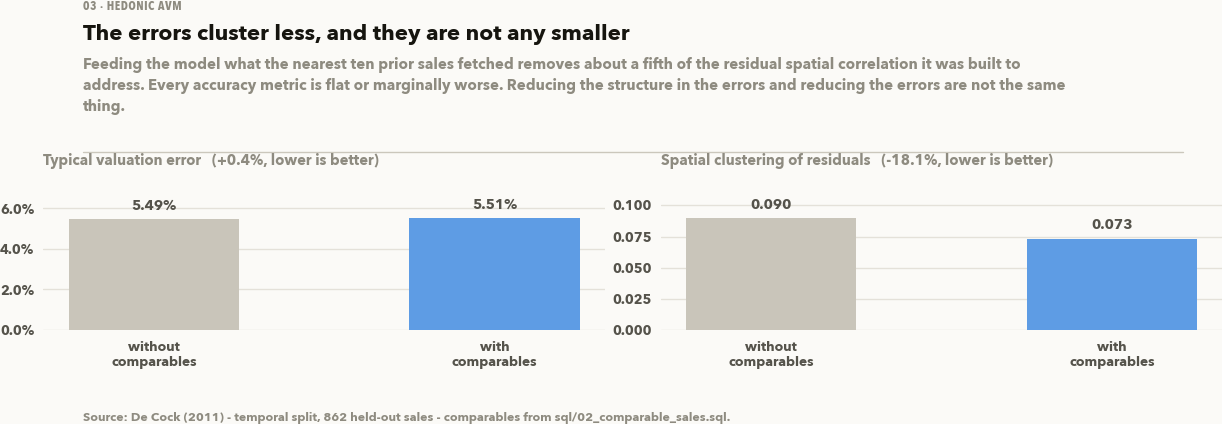

In [23]:
fig, (acc, spa) = plt.subplots(1, 2, figsize=(11.4, 4.4))

for ax, key, as_pct, title, better in [
    (acc, "MdAPE", True, "Typical valuation error", "lower is better"),
    (spa, "Moran's I", False, "Spatial clustering of residuals", "lower is better"),
]:
    values = [comparison.loc["without comparables", key],
              comparison.loc["with comparables", key]]
    bars = ax.bar([0, 1], values, color=[CONTEXT, SUBJECT_FILL], width=0.5)
    ax.set_xticks([0, 1], ["without\ncomparables", "with\ncomparables"])
    ax.set_ylim(0, max(values) * 1.34)
    if as_pct:
        ax.yaxis.set_major_formatter(pct1)
    labels = [f"{v:.2%}" if as_pct else f"{v:.3f}" for v in values]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9.4,
                 color=INK_SECONDARY, fontweight="demibold")
    change = (values[1] - values[0]) / values[0]
    ax.set_title(f"{title}   ({change:+.1%}, {better})", fontsize=9.6,
                 color=INK_MUTED, pad=10, loc="left")

finish(fig, "The errors cluster less, and they are not any smaller",
       "Feeding the model what the nearest ten prior sales fetched removes about a "
       "fifth of the residual spatial correlation it was built to address. Every "
       "accuracy metric is flat or marginally worse. Reducing the structure in the "
       "errors and reducing the errors are not the same thing.",
       source="Source: De Cock (2011) - temporal split, 862 held-out sales - "
              "comparables from sql/02_comparable_sales.sql.")
save(fig, "03_comparable_sales_lift")
plt.show()

**The champion model is unchanged.**

The feature reduced spatial clustering as intended: Moran's I falls from **0.0897 to 0.0734**, an
18% reduction in the spatial correlation of the residuals. Accuracy did not improve.
MdAPE moves 5.49% → 5.51%, PPE10 drops 0.8 points, RMSE rises 1.1%. Every accuracy
metric is flat or marginally worse, and the clustering that remains is still
overwhelmingly significant.

The two results are consistent. Moran's I measures whether errors are
organised in space; MdAPE measures whether they are small. Comparable prices carry
real location information (the correlation with the subject's own price per square
foot is 0.64), but the model had already extracted that information from
`Neighborhood`, the distance and bearing features, and lot characteristics. The new
columns gave the same predictions a smoother spatial surface: the
errors redistribute without shrinking.

This bears on the original diagnosis more than on this feature.
"Residuals cluster in space" suggests the model does not know what nearby
houses cost. Given that information directly, four fifths of
the clustering survives. What remains is something a 1.5-mile radius of recent sale
prices cannot express: micro-location, school attendance boundaries, arterial frontage,
or the fact that Ames's price surface is organised around a university rather
than around a centre.

Notebook 04's Moran's I result therefore survives the most obvious fix. The "what to build
next" list now records it as an open question about unobserved micro-location, replacing
the earlier entry, *add a spatial feature*.

## 10. Does a Ridge / LightGBM blend beat both?

Under the temporal regime the two strongest models disagree about what "better" means:
LightGBM wins the median (MdAPE 5.49% vs 5.82%) and Ridge wins the tail (RMSE $16,579 vs
$17,551). An average of two models can only beat both when they make different errors,
so the blend is measured rather than assumed.

The blend is an average of the two log-price predictions. The one design choice is the
weight, and it is where a blend can overstate its accuracy: tune it on the test set and the result
is a test-set fit, not an estimate. The weight is therefore chosen on out-of-fold predictions
for the training rows (each model's tuned hyperparameters held fixed, the same
neighbourhood-grouped folds as the tuning), and the test set is scored once. A fixed
50/50 blend, which needs no tuning at all, is reported beside it as a reference.

A difference of a few tenths of a point in MdAPE on 862 sales is within noise, so each
blend's MdAPE gain over LightGBM carries a paired-bootstrap interval.

In [24]:
from sklearn.model_selection import cross_val_predict

WEIGHTS = np.round(np.linspace(0, 1, 21), 2)       # weight on Ridge; LightGBM gets the rest
BOOTSTRAPS = 2000


def blend_log(w, ridge_log, gbm_log):
    return w * ridge_log + (1 - w) * gbm_log


blend_rows, blend_meta = [], {}
for regime, (train_idx, test_idx) in REGIMES.items():
    X_train, y_train = universe.loc[train_idx], y_log.loc[train_idx].to_numpy()
    ridge, gbm = results[regime]["Ridge"], results[regime]["LightGBM"]

    # The weight comes from training rows only: out-of-fold predictions, same folds.
    oof = {name: cross_val_predict(clone(results[regime][name]["estimator"]), X_train,
                                   y_train, cv=CV, groups=X_train["Neighborhood"], n_jobs=-1)
           for name in ("Ridge", "LightGBM")}
    oof_rmse = pd.Series({w: np.sqrt(np.mean((blend_log(w, oof["Ridge"], oof["LightGBM"])
                                              - y_train) ** 2)) for w in WEIGHTS})
    w_oof = float(oof_rmse.idxmin())
    blend_meta[regime] = {
        "weight_ridge_oof": w_oof,
        "oof_error_correlation": float(np.corrcoef(oof["Ridge"] - y_train,
                                                   oof["LightGBM"] - y_train)[0, 1]),
    }

    actual = ridge["actual"]
    variants = {"Ridge": (1.0, ridge["dollars"]), "LightGBM": (0.0, gbm["dollars"])}
    for label, w in (("Blend, weight from training folds", w_oof), ("Blend, 50/50", 0.5)):
        # Smearing from training residuals only, exactly as for the single models.
        train_log = blend_log(w, ridge["estimator"].predict(X_train),
                              gbm["estimator"].predict(X_train))
        smear = duan_smearing_factor(y_train - train_log)
        variants[label] = (w, predict_dollars(blend_log(w, ridge["log_pred"], gbm["log_pred"]),
                                              smear))

    # Paired bootstrap over test sales: the same resample scores every variant.
    rng = np.random.default_rng(SEED)
    draws = rng.integers(0, len(actual), (BOOTSTRAPS, len(actual)))
    ape = {k: np.abs(v - actual) / actual for k, (_, v) in variants.items()}
    gbm_mdape = np.median(ape["LightGBM"][draws], axis=1)

    for label, (w, dollars) in variants.items():
        card = scorecard(actual, dollars)
        row = {"regime": regime, "model": label, "weight on Ridge": w,
               "MdAPE": card["MdAPE"], "PPE10": card["PPE10"], "RMSE": card["RMSE"]}
        if label.startswith("Blend"):
            diff = np.median(ape[label][draws], axis=1) - gbm_mdape
            row.update({"MdAPE gain vs LightGBM": card["MdAPE"] - cards.loc[(regime, "LightGBM"), "MdAPE"],
                        "95% CI low": np.percentile(diff, 2.5),
                        "95% CI high": np.percentile(diff, 97.5),
                        "P(blend better)": float(np.mean(diff < 0))})
        blend_rows.append(row)

blend_table = pd.DataFrame(blend_rows).set_index(["regime", "model"])
for regime, meta in blend_meta.items():
    print(f"{regime:9s} weight on Ridge chosen on training folds: {meta['weight_ridge_oof']:.2f}"
          f" · out-of-fold error correlation {meta['oof_error_correlation']:.2f}")

(PROCESSED / "blend_summary.json").write_text(json.dumps({
    "meta": blend_meta,
    "table": {f"{r}|{m}": {k: (None if pd.isna(v) else float(v)) for k, v in row.items()}
              for (r, m), row in blend_table.iterrows()},
    "promoted": False,
}, indent=2))
blend_table.round(4)

random    weight on Ridge chosen on training folds: 0.65 · out-of-fold error correlation 0.77
temporal  weight on Ridge chosen on training folds: 0.65 · out-of-fold error correlation 0.81


weight on Ridge   MdAPE   PPE10        RMSE  MdAPE gain vs LightGBM  95% CI low  95% CI high  \
regime   model                                                                                                                             
random   Ridge                                         1.00  0.0557  0.7695  18092.6849                     NaN         NaN          NaN   
         LightGBM                                      0.00  0.0515  0.7678  15869.1920                     NaN         NaN          NaN   
         Blend, weight from training folds             0.65  0.0511  0.7894  16008.8591                 -0.0004     -0.0053       0.0053   
         Blend, 50/50                                  0.50  0.0499  0.7977  15555.3511                 -0.0016     -0.0055       0.0032   
temporal Ridge                                         1.00  0.0582  0.7564  16578.7249                     NaN         NaN          NaN   
         LightGBM                                      0.00  0.0549  0.7657  17551.0366                     NaN         NaN          NaN   
         Blend, weight from training folds             0.65  0.0538  0.7842  15844.3748                 -0.0011     -0.0048       0.0031   
         Blend, 50/50                                  0.50  0.0522  0.7831  15912.3964                 -0.0027     -0.0060       0.0005   

                                            P(blend better)  
regime   model                                               
random   Ridge                                          NaN  
         LightGBM                                       NaN  
         Blend, weight from training folds           0.4910  
         Blend, 50/50                                0.6605  
temporal Ridge                                          NaN  
         LightGBM                                       NaN  
         Blend, weight from training folds           0.6950  
         Blend, 50/50                                0.9475

**The blend helps, modestly and not everywhere, and the champion is not changed.**

With the weight chosen on training folds (65% Ridge in both regimes), the temporal-holdout
blend scores MdAPE 5.38%, PPE10 78.4%, RMSE $15,844 against LightGBM's 5.49%, 76.6% and
$17,551. What is solid and what is not:

| Metric | Temporal regime | Random regime | Verdict |
|---|---|---|---|
| PPE10 | 76.6% → 78.4% | 76.8% → 78.9% | Better in both |
| RMSE | $17,551 → $15,844 (−10%) | $15,869 → $16,009 (+1%) | Better out-of-time only |
| MdAPE | 5.49% → 5.38% | 5.15% → 5.11% | Inside noise: 95% intervals span zero in both |
| 5% MdAPE bar | Not cleared | Not cleared | — |

The fixed 50/50 blend happens to score better on the temporal test set (MdAPE 5.22%, still
inside a 95% interval that touches zero), but choosing it because it scored better there
would be tuning on the test set, so it is not the reported result.

The folds and the test set agree on the metric the weight was chosen for: 65% Ridge also
beats 50/50 on test RMSE ($15,844 vs $15,912). They disagree on MdAPE, where the test set
favours LightGBM more than the folds do. One plausible cause, not tested here: the folds
hold out whole neighbourhoods, asking each model to value houses somewhere it has never
seen, while every neighbourhood in the 2009–2010 test set was also sold in 2006–2008.
Grouped folds guard against leakage between neighbouring sales, but they do not closely
reproduce deployment conditions.

The champion stays LightGBM. The out-of-time RMSE gain is real, but the headline
metric, MdAPE, does not move beyond noise, the 5% bar stays out of reach, and every
downstream artefact (the conformal intervals, the Mondrian bands, the credit figures, the
served model card) is calibrated on the single model. Promoting the blend would mean
re-deriving all of them for a gain the evaluation cannot distinguish from zero on the
primary metric. The measurement is recorded, not deployed.

## 11. Summary

| Finding | Consequence |
|---|---|
| Temporal MdAPE is 4–7% worse than random, in relative terms, because Ames barely moved | Any AVM accuracy claim must state its split design; in a cyclical market the gap would be larger |
| Duan smearing removes a systematic under-valuation | Dollar values are unbiased before they become LTVs in nb 08 |
| Errors grouped by sale price slope from high to low | Mostly a grouping artefact; separated in nb 04 (≈2–3% real over-valuation at the cheap end, none at the top) |
| The best point estimate still misses by several percent typically | Per-property conformal intervals in nb 04 |
| Comparable sales cut Moran's I 18% and improved nothing | Accuracy metrics were flat or slightly worse; the remaining clustering is not explained by the level of nearby prices |
| The first pass's true error is now measured | Quantified cost of the Model Risk Log defects |
| A Ridge / LightGBM blend lifts PPE10 ~2 points and cuts out-of-time RMSE 10%, but its MdAPE gain is inside noise | Measured and recorded; not promoted, because every downstream calibration would have to be redone for no distinguishable headline gain |